## Nucleosynthetic yields
These are key to every chemical evolution model. Chempy supports three nucleosynthetic channels at the moment:
- Core-Collapse Supernova (CC-SN)
- Supernova of type Ia (SN Ia)
- Winds from Asymptotic Giant Branch phase of stars (AGB)

In [1]:
#
import sys
sys.path.append("../")

In [2]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [19]:
from Chempy.parameter import ModelParameters
from Chempy.yields import SN2_feedback, AGB_feedback, SN1a_feedback, Hypernova_feedback

In [20]:
from Chempy.infall import PRIMORDIAL_INFALL, INFALL

In [5]:
 # This loads the default parameters, you can check and change them in paramter.py

a = ModelParameters()

In [6]:
# Implemented SN Ia yield tables

a.yield_table_name_1a_list 

['Iwamoto', 'Thielemann', 'Seitenzahl', 'TNG']

In [7]:
# AGB yields implemented

a.yield_table_name_agb_list 

['Karakas',
 'Nugrid',
 'Karakas_net_yield',
 'Ventura_net',
 'Karakas16_net',
 'TNG_net',
 'Nomoto2013']

In [8]:
# CC-SN yields implemented

a.yield_table_name_sn2_list 

['chieffi04',
 'OldNugrid',
 'Nomoto2013',
 'Portinari_net',
 'francois',
 'chieffi04_net',
 'Nomoto2013_net',
 'NuGrid_net',
 'West17_net',
 'TNG_net',
 'CL18_net',
 'Frischknecht16_net']

In [9]:
# Hypernova yields (is mixed with Nomoto2013 CC-SN yields for stars more massive than 25Msun)

a.yield_table_name_hn_list 

['Nomoto2013']

In [10]:
# Here we show the available mass and metallicity range for each yield set

# First for CC-SNe

print('Available CC-SN yield parameter range')
for item in a.yield_table_name_sn2_list:
    basic_sn2 = SN2_feedback()
    getattr(basic_sn2, item)()
    print('----------------------------------')
    print('yield table name: ',item)
    print('provided masses: ', basic_sn2.masses)
    print('provided metallicities',basic_sn2.metallicities)
    

Available CC-SN yield parameter range
----------------------------------
yield table name:  chieffi04
provided masses:  [13, 15, 20, 25, 30, 35]
provided metallicities [0.e+00 1.e-06 1.e-04 1.e-03 6.e-03 2.e-02]
----------------------------------
yield table name:  OldNugrid
provided masses:  [15 20 25 32 60]
provided metallicities [0.02, 0.01]
----------------------------------
yield table name:  Nomoto2013
provided masses:  [13 15 18 20 25 30 40]
provided metallicities [0.05, 0.02, 0.008, 0.004, 0.001]
----------------------------------
yield table name:  Portinari_net
provided masses:  [6.0, 7.0, 9.0, 12.0, 15.0, 20.0, 30.0, 40.0, 60.0, 100.0, 120.0]
provided metallicities [0.0004, 0.004, 0.008, 0.02, 0.05]
----------------------------------
yield table name:  francois
provided masses:  [ 11.  12.  13.  15.  18.  19.  20.  22.  25.  30.  35.  40.  50.  60.
  70.  80.  90. 100.]
provided metallicities [0.02]
----------------------------------
yield table name:  chieffi04_net
provided

../Chempy/yields.py:1288: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.metallicities = list(f['Metallicities'].value)
../Chempy/yields.py:1289: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.masses = f['Masses'].value
../Chempy/yields.py:1296: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  z_name = f['Yield_names'].value[z_index].decode('utf-8')
../Chempy/yields.py:1299: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  ejecta_mass = f['Yields/'+z_name+'/Ejected_mass'].value


----------------------------------
yield table name:  Frischknecht16_net
provided masses:  [15 20 25 40]
provided metallicities [0.0134, 0.001, 1e-05]


Hyper Nova (HN) is only provided for Nomoto 2013 CC-SN yields and it is mixed 50/50 with it for stars with mass >= 25 Msun


In [11]:
# Then for Hypernovae

print('Available HN yield parameter range')
for item in a.yield_table_name_hn_list:
    basic_hn = Hypernova_feedback()
    getattr(basic_hn, item)()
    print('----------------------------------')
    print('yield table name: ',item)
    print('provided masses: ', basic_hn.masses)
    print('provided metallicities',basic_hn.metallicities)

Available HN yield parameter range
----------------------------------
yield table name:  Nomoto2013
provided masses:  [20 25 30 40]
provided metallicities [0.05, 0.02, 0.008, 0.004, 0.001]


In [12]:
# Here for AGB stars

print('Available AGB yield parameter range')
for item in a.yield_table_name_agb_list:
    basic_agb = AGB_feedback()
    getattr(basic_agb, item)()
    print('----------------------------------')
    print('yield table name: ',item)
    print('provided masses: ', basic_agb.masses)
    print('provided metallicities',basic_agb.metallicities)

Available AGB yield parameter range
----------------------------------
yield table name:  Karakas
provided masses:  [1.   1.25 1.5  1.75 1.9  2.   2.25 2.5  3.   3.5  4.   4.5  5.   5.5
 6.   6.5 ]
provided metallicities [0.02, 0.008, 0.004, 0.0001]
----------------------------------
yield table name:  Nugrid
provided masses:  [1.65 2.   3.   5.  ]
provided metallicities [0.02, 0.01]
----------------------------------
yield table name:  Karakas_net_yield
provided masses:  [1.   1.25 1.5  1.75 1.9  2.   2.25 2.5  3.   3.5  4.   4.5  5.   5.5
 6.   6.5 ]
provided metallicities [0.02, 0.008, 0.004, 0.0001]
----------------------------------
yield table name:  Ventura_net
provided masses:  [8.   7.5  7.   6.5  6.   5.5  5.   4.5  4.   3.5  3.   2.5  2.25 2.
 1.75 1.5  1.25 1.  ]
provided metallicities [0.04, 0.018, 0.008, 0.004, 0.001, 0.0003]
----------------------------------
yield table name:  Karakas16_net
provided masses:  [8.   7.   6.   5.5  5.   4.75 4.5  4.25 4.   3.75 3.5  3.25 3

../Chempy/yields.py:1425: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.metallicities = list(f['Metallicities'].value)
../Chempy/yields.py:1426: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.masses = f['Masses'].value
../Chempy/yields.py:1433: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  z_name = f['Yield_names'].value[z_index].decode('utf-8')
../Chempy/yields.py:1436: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  ejecta_mass = f['Yields/'+z_name+'/Ejected_mass'].value


TypeError: can only concatenate list (not "dict_keys") to list

In [16]:
# And for SN Ia

print('Available SN Ia yield parameter range')
for item in a.yield_table_name_1a_list:
    basic_1a = SN1a_feedback()
    getattr(basic_1a, item)()
    print('----------------------------------')
    print('yield table name: ',item)
    print('provided masses: ', basic_1a.masses)
    print('provided metallicities',basic_1a.metallicities)

Available SN Ia yield parameter range
----------------------------------
yield table name:  Iwamoto
provided masses:  [1.38]
provided metallicities [0.02, 0.0]
----------------------------------
yield table name:  Thielemann
provided masses:  [1.37409]
provided metallicities [0.02]
----------------------------------
yield table name:  Seitenzahl
provided masses:  [1.4004633930489443]
provided metallicities [0.02]
----------------------------------
yield table name:  TNG
provided masses:  [1.3743416]
provided metallicities [0.02]


In [21]:
from Chempy.data_to_test import elements_plot
from Chempy.solar_abundance import solar_abundances

## Elements availability
usually not all elements are provided by a yield table. We have a handy plotting routine to show which elements are given. We check for the default and the alternative yield table.

[0.0]

<Figure size 640x480 with 0 Axes>

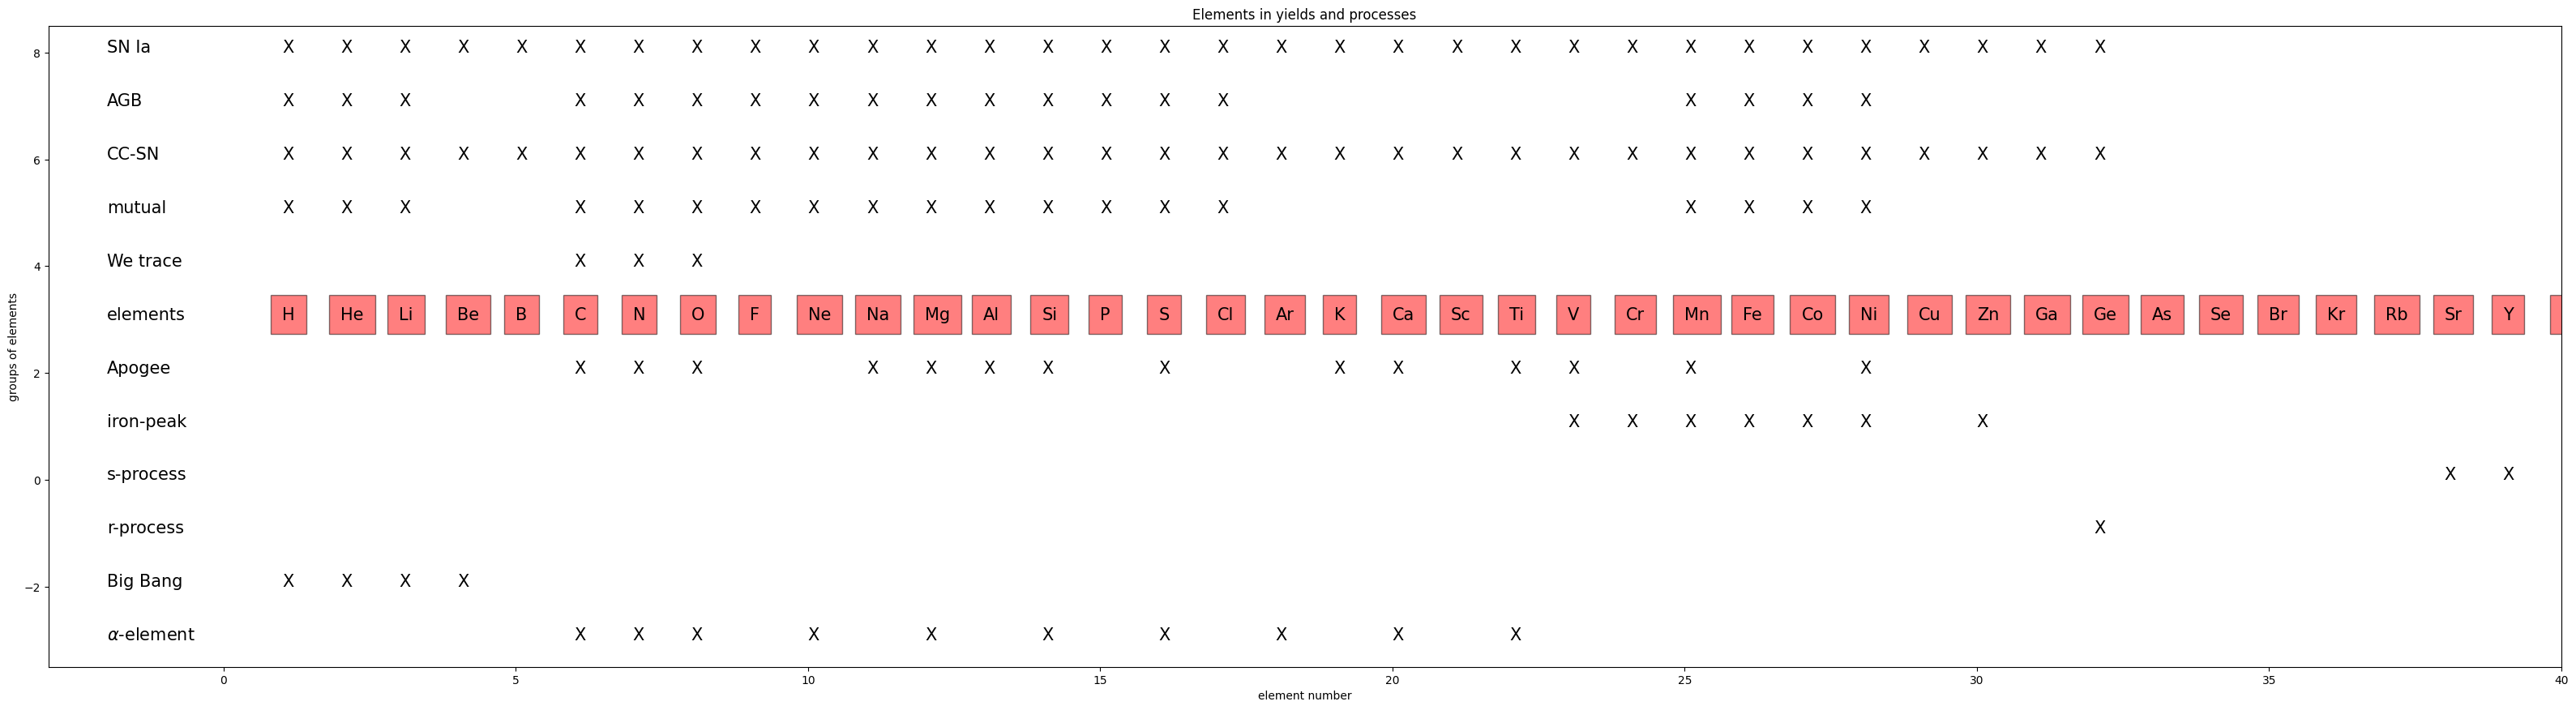

In [18]:
# To get the element list we initialise the solar abundance class

basic_solar = solar_abundances()




# we load the default yield set:

basic_sn2 = SN2_feedback()
getattr(basic_sn2, "Nomoto2013")()
basic_1a = SN1a_feedback()
getattr(basic_1a, "Seitenzahl")()
basic_agb = AGB_feedback()
getattr(basic_agb, "Karakas_net_yield")()


#Now we plot the elements available for the default yield set and which elements are available for specific surveys and come from which nucleosynthetic channel

elements_plot('default', basic_agb.elements,basic_sn2.elements,basic_1a.elements,['C','N','O'], basic_solar.table,40)

[0.0]

<Figure size 640x480 with 0 Axes>

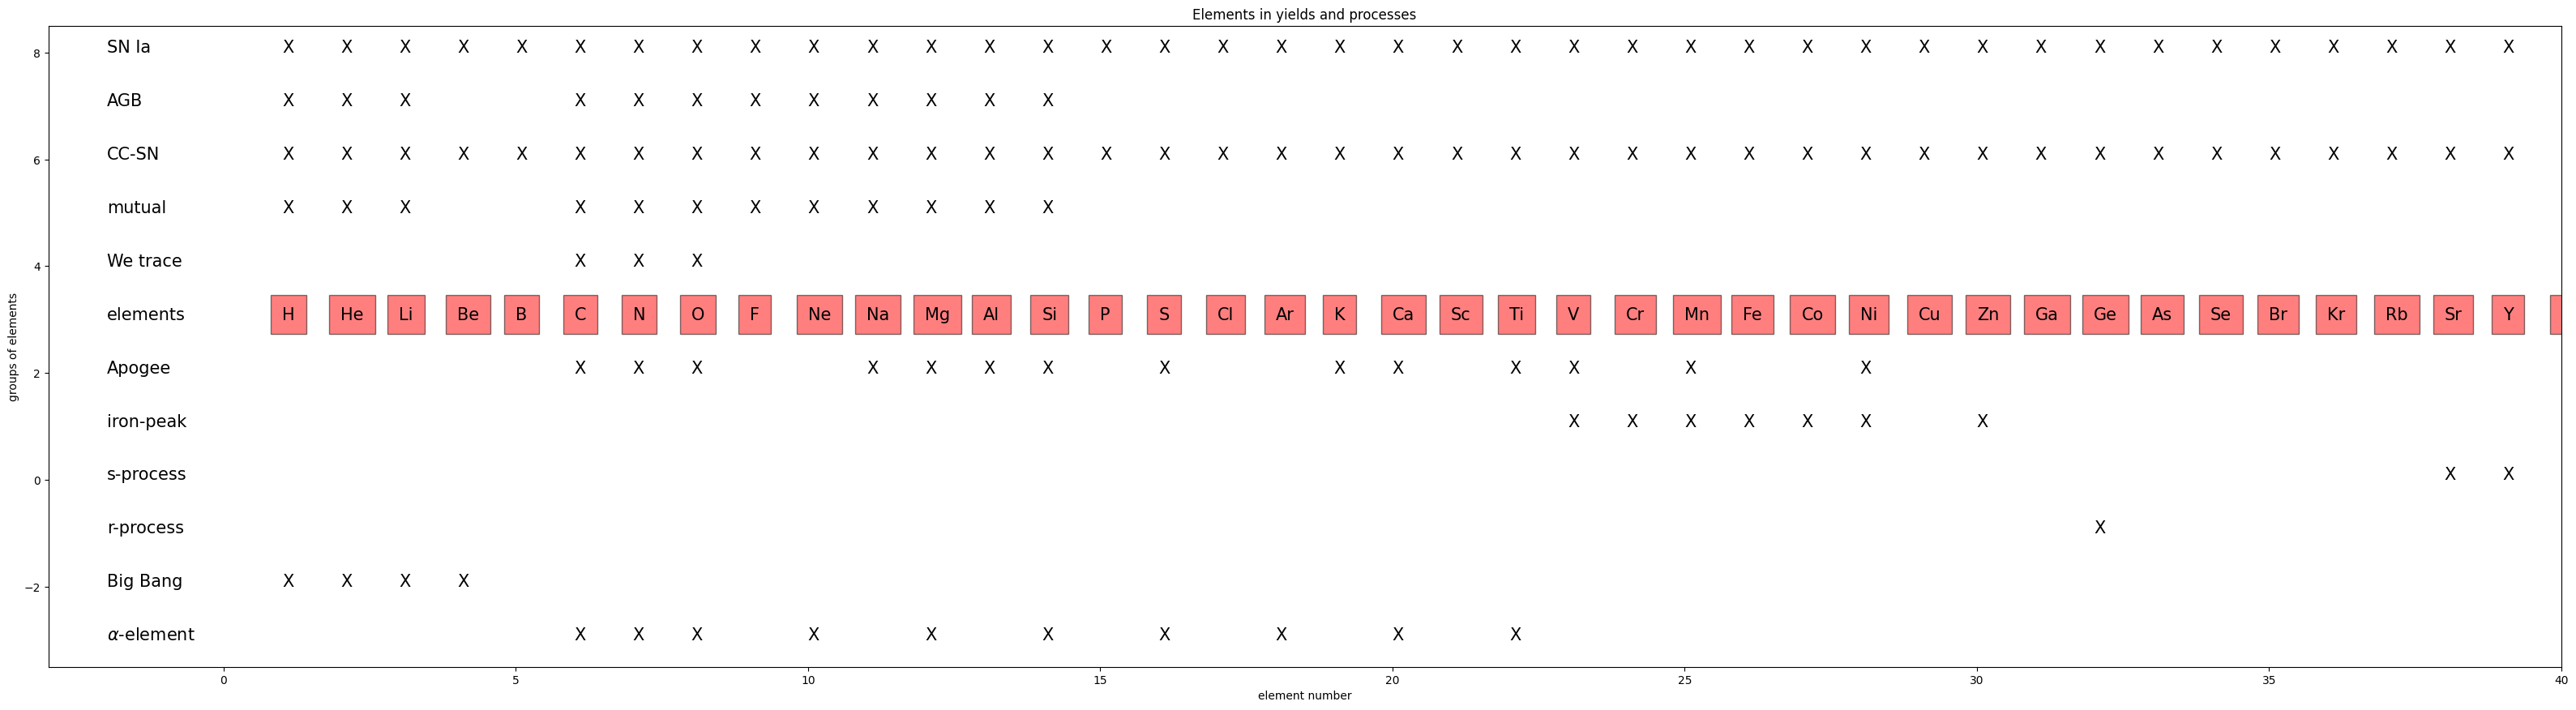

In [22]:
# Then we load the alternative yield set:

basic_sn2 = SN2_feedback()
getattr(basic_sn2, "chieffi04")()
basic_1a = SN1a_feedback()
getattr(basic_1a, "Thielemann")()
basic_agb = AGB_feedback()
getattr(basic_agb, "Ventura_net")()

#And again plot the elements available 

elements_plot('alternative', basic_agb.elements,basic_sn2.elements,basic_1a.elements,['C','N','O'], basic_solar.table,40)

## CC-SN yields
Here we visualise the yield in [X/Fe] for the whole grid in masses and metallicities for two different yields sets
- Interestingly CC-SN ejecta can be Solar in their alpha-enhancement for low-mass progenitors (=13Msun)
- Ths effect is even stronger for the Chieffi04 yields

../Chempy/data_to_test.py:279: MatplotlibDeprecationWarning: 
The 'verts' parameter of scatter() was deprecated in Matplotlib 3.2 and will be removed two minor releases later. If any parameter follows 'verts', they should be passed as keyword, not positionally.
  ax.scatter(metallicity, alpha_enhancement, s=20, c=None, marker=u'o', cmap=None, norm=None, vmin=None, vmax=None, alpha=None, linewidths=None, verts=None, edgecolors=None)


<Figure size 640x480 with 0 Axes>

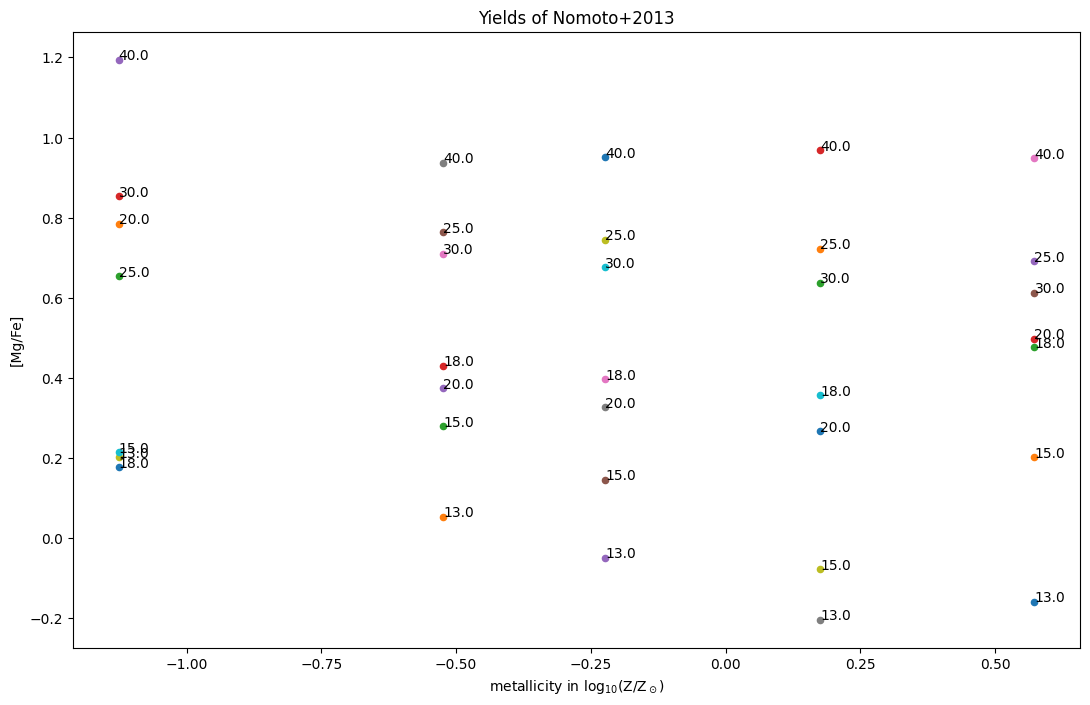

In [23]:
# We need solar abundances for normalisation of the feedback

basic_solar.Asplund09()

# Then we plot the [Mg/Fe] of Nomoto+ 2013 for all masses and metallicities 

from Chempy.data_to_test import yield_plot
basic_sn2 = SN2_feedback()
getattr(basic_sn2, "Nomoto2013")()
yield_plot('Nomoto+2013', basic_sn2, basic_solar, 'Mg')

<Figure size 640x480 with 0 Axes>

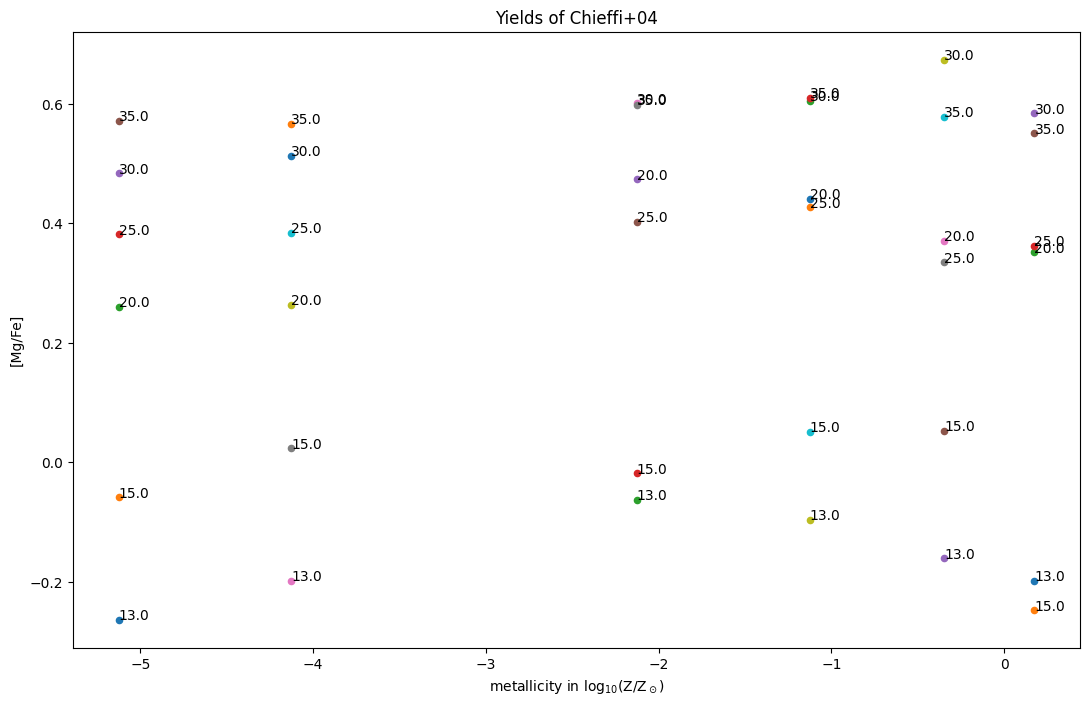

In [24]:
# And we plot the same for Chieffi+ 2004 CC-yields

basic_sn2 = SN2_feedback()
getattr(basic_sn2, "chieffi04")()
yield_plot('Chieffi+04', basic_sn2, basic_solar, 'Mg')

## Yield comparison
We can plot the differences of the two yield tables for different elements (They are copied into the output/ folder). Here only the result for Ti is displayed.

../Chempy/data_to_test.py:329: MatplotlibDeprecationWarning: 
The 'verts' parameter of scatter() was deprecated in Matplotlib 3.2 and will be removed two minor releases later. If any parameter follows 'verts', they should be passed as keyword, not positionally.
  ax.scatter(metallicity, alpha_enhancement, s=20*mass, c='b', marker=u'o', cmap=None, norm=None, vmin=None, vmax=None, alpha=0.5, linewidths=None, verts=None, edgecolors=None)
../Chempy/data_to_test.py:330: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.annotate(xy = (metallicity, alpha_enhancement), s = mass, color = 'b')
../Chempy/data_to_test.py:344: MatplotlibDeprecationWarning: 
The 'verts' parameter of scatter() was deprecated in Matplotlib 3.2 and will be removed two minor releases later. If any parameter follows 'verts', they should be passed as keyword, not positionally.
  ax.scatter(meta

<Figure size 640x480 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

<Figure size 1300x800 with 0 Axes>

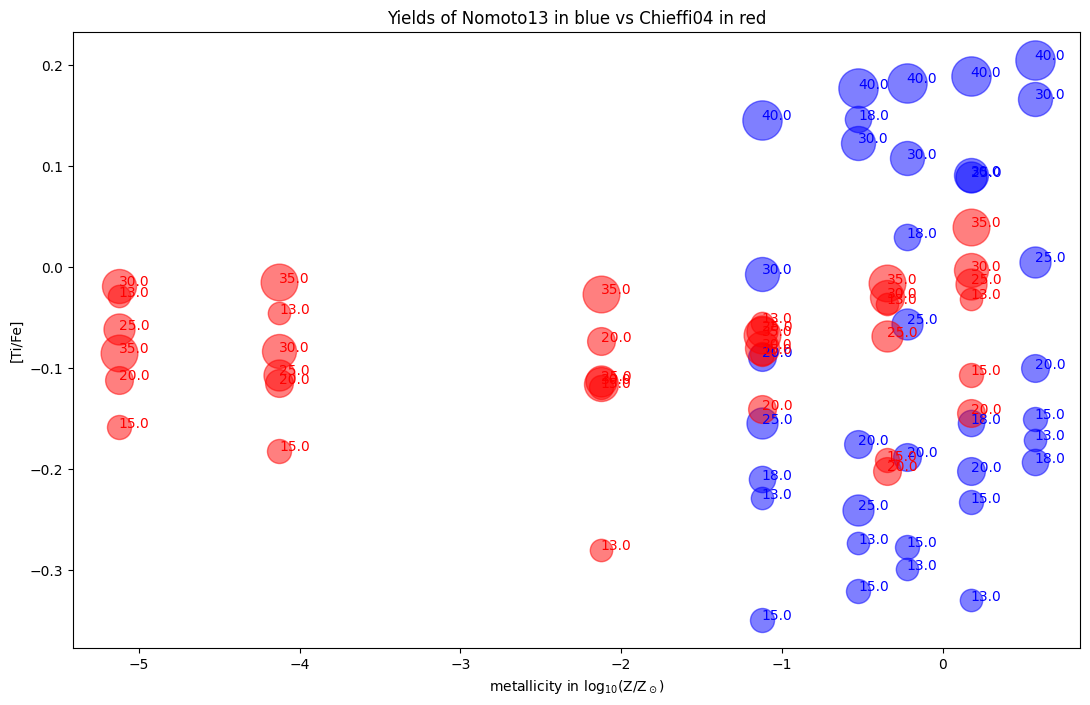

In [25]:
# Now we plot a comparison for different elements between Nomoto+ 2013 and Chieffi+ 2004 CC-yields: 
# You can look into the output/ folder and see the comparison for all those elements

from Chempy.data_to_test import yield_comparison_plot
basic_sn2 = SN2_feedback()
getattr(basic_sn2, "Nomoto2013")()
basic_sn2_chieffi = SN2_feedback()
getattr(basic_sn2_chieffi, "chieffi04")()
for element in ['C', 'N', 'O', 'Mg', 'Ca', 'Na', 'Al', 'Mn','Ti']:
    yield_comparison_plot('Nomoto13', 'Chieffi04', basic_sn2, basic_sn2_chieffi, basic_solar, element)

## AGB yield comparison
We have a look at the Carbon and Nitrogen yields.
We see that high mass AGB stars produce less fraction of C than low-mass AGB stars and that its vice versa for N. The C/N ratio should be IMF sensitive.

../Chempy/data_to_test.py:391: MatplotlibDeprecationWarning: 
The 'verts' parameter of scatter() was deprecated in Matplotlib 3.2 and will be removed two minor releases later. If any parameter follows 'verts', they should be passed as keyword, not positionally.
  ax.scatter(metallicity, fractional_feedback, s=20*mass, c='b', marker=u'o', cmap=None, norm=None, vmin=None, vmax=None, alpha=0.5, linewidths=None, verts=None, edgecolors=None)
../Chempy/data_to_test.py:392: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.annotate(xy = (metallicity, fractional_feedback), s = mass, color = 'b')
../Chempy/data_to_test.py:405: MatplotlibDeprecationWarning: 
The 'verts' parameter of scatter() was deprecated in Matplotlib 3.2 and will be removed two minor releases later. If any parameter follows 'verts', they should be passed as keyword, not positionally.
  ax.scatter(

<Figure size 640x480 with 0 Axes>

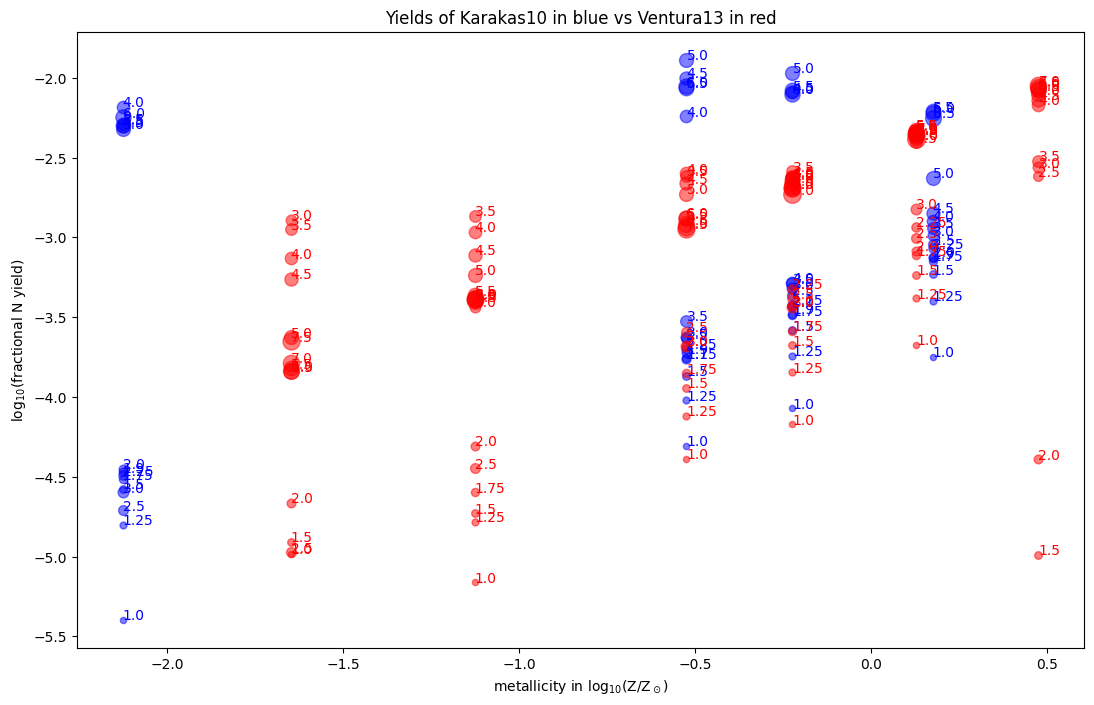

In [26]:
# We can also plot a comparison between Karakas+ 2010 and Ventura+ 2013 AGB-yields
# Here we plot the fractional N yield

from Chempy.data_to_test import fractional_yield_comparison_plot
basic_agb = AGB_feedback()
getattr(basic_agb, "Karakas_net_yield")()
basic_agb_ventura = AGB_feedback()
getattr(basic_agb_ventura, "Ventura_net")()

fractional_yield_comparison_plot('Karakas10', 'Ventura13', basic_agb, basic_agb_ventura, basic_solar, 'N')
#The next line produces an error in the 0.2 version. Needs checking 
#fractional_yield_comparison_plot('Karakas10', 'Ventura13', basic_agb, basic_agb_ventura, basic_solar, 'C')


## Yield table query and remnant fraction
- Here you see how the yield tables are queried (the metallicity accesses the yield table)
- For net yield the remnant fraction + the 'unprocessed mass in winds' sums to unity.
- The changes come from destroyed Hydrogen that is fused into other elements

In [27]:
# Different entries of the yield table are queried

print('Mass, Remnant mass fraction, Unprocessed mass in winds fraction, destroyed Hydrogen of total mass')
for i in range(len(basic_agb.masses)):
    print(basic_agb.table[0.02]['Mass'][i],basic_agb.table[0.02]['mass_in_remnants'][i],basic_agb.table[0.02]['unprocessed_mass_in_winds'][i],basic_agb.table[0.02]['H'][i])

Mass, Remnant mass fraction, Unprocessed mass in winds fraction, destroyed Hydrogen of total mass
6.5 0.14815384615384614 0.8518466340664187 -0.06457611230769231
6.0 0.15483333333333335 0.8451678501706426 -0.05858918
5.5 0.16363636363636364 0.8363640753171778 -0.050066427272727275
5.0 0.1758 0.8242003459953604 -0.03642034599999999
4.5 0.18933333333333333 0.810667091437056 -0.024126477777777777
4.0 0.198 0.8020001241693968 -0.015764474749999997
3.5 0.20514285714285713 0.7948567935183549 -0.026789563142857138
3.0 0.22733333333333336 0.7726668593010996 -0.023175398666666663
2.5 0.2652 0.7348002118095827 -0.012012815599999995
2.25 0.29333333333333333 0.706666844514067 -0.006690502222222218
2.0 0.32 0.6800001345373927 -0.005093961999999995
1.9 0.3315789473684211 0.6684205877240146 -0.005711034736842102
1.75 0.3514285714285714 0.6485713542264424 -0.006746394285714282
1.5 0.39999999999999997 0.5999991703923481 -0.008554657333333332
1.25 0.45919999999999994 0.5408002224986284 -0.00983531439999

## SN Ia yields
Here we see that the SNIa ejecta differ quite strongly for our two yieldtables

In [28]:
# Here we compare the yields for different iron-peak elements for Seitenzahl+ 2013 and Thielemann+ 2003 SNIa tables

basic_1a = SN1a_feedback()
getattr(basic_1a, 'Seitenzahl')()
basic_1a_alternative = SN1a_feedback()
getattr(basic_1a_alternative, 'Thielemann')()
print('Mass fraction of SN1a ejecta: Cr, Mn, Fe and Ni')
print('Seitenzahl2013')
print(basic_1a.table[0.02]['Cr'],basic_1a.table[0.02]['Mn'],basic_1a.table[0.02]['Fe'],basic_1a.table[0.02]['Ni'])
print('Thielemann2003')
print(basic_1a_alternative.table[0.02]['Cr'],basic_1a_alternative.table[0.02]['Mn'],basic_1a_alternative.table[0.02]['Fe'],basic_1a_alternative.table[0.02]['Ni'])


Mass fraction of SN1a ejecta: Cr, Mn, Fe and Ni
Seitenzahl2013
[0.00735471] [0.00949686] [0.52839653] [0.05283965]
Thielemann2003
[0.00394618] [0.00475951] [0.55984251] [0.08281772]
